<a href="https://www.kaggle.com/code/omborse771924/arsenal-fc-premier-league-champions-campaign-eda?scriptVersionId=331097341" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abbas829/arsenal-fc-premier-league-champions-campaign/premier_league_player_match_stats.csv


## Loading Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abbas829/arsenal-fc-premier-league-champions-campaign/premier_league_player_match_stats.csv")


In [3]:
df.head()

,league,season,game,Team,Player,jersey_number,nation,Position,Age,Minutes,...,Match_Week,Match_Day,Kickoff_Time,Home_Team,Away_Team,Match_Score,Venue,Attendance,Referee,Match_Report
0,ENG-Premier League,2526,2025-08-15 Liverpool-Bournemouth,Bournemouth,Adam Smith,15,ENG,RB,34-108,89,...,1,Fri,20:00,Liverpool,Bournemouth,4–2,Anfield,60315.0,Anthony Taylor,/en/matches/a071faa8/Liverpool-Bournemouth-Aug...
1,ENG-Premier League,2526,2025-08-15 Liverpool-Bournemouth,Bournemouth,Adrien Truffert,3,FRA,LB,23-268,90,...,1,Fri,20:00,Liverpool,Bournemouth,4–2,Anfield,60315.0,Anthony Taylor,/en/matches/a071faa8/Liverpool-Bournemouth-Aug...
2,ENG-Premier League,2526,2025-08-15 Liverpool-Bournemouth,Bournemouth,Alex Scott,8,ENG,AM,21-359,73,...,1,Fri,20:00,Liverpool,Bournemouth,4–2,Anfield,60315.0,Anthony Taylor,/en/matches/a071faa8/Liverpool-Bournemouth-Aug...
3,ENG-Premier League,2526,2025-08-15 Liverpool-Bournemouth,Bournemouth,Antoine Semenyo,24,GHA,RW,25-220,90,...,1,Fri,20:00,Liverpool,Bournemouth,4–2,Anfield,60315.0,Anthony Taylor,/en/matches/a071faa8/Liverpool-Bournemouth-Aug...
4,ENG-Premier League,2526,2025-08-15 Liverpool-Bournemouth,Bournemouth,Bafodé Diakité,18,FRA,CB,24-221,90,...,1,Fri,20:00,Liverpool,Bournemouth,4–2,Anfield,60315.0,Anthony Taylor,/en/matches/a071faa8/Liverpool-Bournemouth-Aug...


In [4]:
df.tail()

,league,season,game,Team,Player,jersey_number,nation,Position,Age,Minutes,...,Match_Week,Match_Day,Kickoff_Time,Home_Team,Away_Team,Match_Score,Venue,Attendance,Referee,Match_Report
11487,ENG-Premier League,2526,2026-05-24 West Ham United-Leeds United,West Ham United,Mateus Fernandes,18,POR,DM,21-318,90,...,38,Sun,16:00,West Ham United,Leeds United,3–0,London Stadium,62471.0,Anthony Taylor,/en/matches/df8c12d9/West-Ham-United-Leeds-Uni...
11488,ENG-Premier League,2526,2026-05-24 West Ham United-Leeds United,West Ham United,Mohamadou Kanté,55,FRA,MF,20-246,3,...,38,Sun,16:00,West Ham United,Leeds United,3–0,London Stadium,62471.0,Anthony Taylor,/en/matches/df8c12d9/West-Ham-United-Leeds-Uni...
11489,ENG-Premier League,2526,2026-05-24 West Ham United-Leeds United,West Ham United,Pablo,19,BRA,AM,22-142,45,...,38,Sun,16:00,West Ham United,Leeds United,3–0,London Stadium,62471.0,Anthony Taylor,/en/matches/df8c12d9/West-Ham-United-Leeds-Uni...
11490,ENG-Premier League,2526,2026-05-24 West Ham United-Leeds United,West Ham United,Tomáš Souček,28,CZE,DM,31-086,90,...,38,Sun,16:00,West Ham United,Leeds United,3–0,London Stadium,62471.0,Anthony Taylor,/en/matches/df8c12d9/West-Ham-United-Leeds-Uni...
11491,ENG-Premier League,2526,2026-05-24 West Ham United-Leeds United,West Ham United,Valentín Castellanos,11,ARG,FW,27-233,87,...,38,Sun,16:00,West Ham United,Leeds United,3–0,London Stadium,62471.0,Anthony Taylor,/en/matches/df8c12d9/West-Ham-United-Leeds-Uni...


In [5]:
df.describe

<bound method NDFrame.describe of                    league  season                                     game  \
0      ENG-Premier League    2526         2025-08-15 Liverpool-Bournemouth   
1      ENG-Premier League    2526         2025-08-15 Liverpool-Bournemouth   
2      ENG-Premier League    2526         2025-08-15 Liverpool-Bournemouth   
3      ENG-Premier League    2526         2025-08-15 Liverpool-Bournemouth   
4      ENG-Premier League    2526         2025-08-15 Liverpool-Bournemouth   
...                   ...     ...                                      ...   
11487  ENG-Premier League    2526  2026-05-24 West Ham United-Leeds United   
11488  ENG-Premier League    2526  2026-05-24 West Ham United-Leeds United   
11489  ENG-Premier League    2526  2026-05-24 West Ham United-Leeds United   
11490  ENG-Premier League    2526  2026-05-24 West Ham United-Leeds United   
11491  ENG-Premier League    2526  2026-05-24 West Ham United-Leeds United   

                  Team       

In [6]:
df.isnull()

,league,season,game,Team,Player,jersey_number,nation,Position,Age,Minutes,...,Match_Week,Match_Day,Kickoff_Time,Home_Team,Away_Team,Match_Score,Venue,Attendance,Referee,Match_Report
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11487,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11488,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11489,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11490,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

league                 0
season                 0
game                   0
Team                   0
Player                 0
jersey_number          0
nation                 0
Position               0
Age                    0
Minutes                0
Goals                  0
Assists                0
Penalty_Goals          0
Penalty_Attempts       0
Shots                  0
Shots_On_Target        0
Yellow_Cards           0
Red_Cards              0
Fouls_Committed        0
Fouls_Drawn            0
Offsides               0
Crosses                0
Tackles_Won            0
Interceptions          0
Own_Goals              0
Penalties_Won          0
Penalties_Conceded     0
game_id                0
Match_Date             0
Match_Week             0
Match_Day              0
Kickoff_Time           0
Home_Team              0
Away_Team              0
Match_Score            0
Venue                  0
Attendance            29
Referee                0
Match_Report           0
dtype: int64

In [8]:
# Remove commas and convert to numeric
df["Attendance"] = (
    df["Attendance"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Attendance"] = pd.to_numeric(
    df["Attendance"],
    errors="coerce"
)

# Fill missing values
df["Attendance"] = df["Attendance"].fillna(
    df["Attendance"].median()
)

print(df.isnull().sum())

league                0
season                0
game                  0
Team                  0
Player                0
jersey_number         0
nation                0
Position              0
Age                   0
Minutes               0
Goals                 0
Assists               0
Penalty_Goals         0
Penalty_Attempts      0
Shots                 0
Shots_On_Target       0
Yellow_Cards          0
Red_Cards             0
Fouls_Committed       0
Fouls_Drawn           0
Offsides              0
Crosses               0
Tackles_Won           0
Interceptions         0
Own_Goals             0
Penalties_Won         0
Penalties_Conceded    0
game_id               0
Match_Date            0
Match_Week            0
Match_Day             0
Kickoff_Time          0
Home_Team             0
Away_Team             0
Match_Score           0
Venue                 0
Attendance            0
Referee               0
Match_Report          0
dtype: int64


In [9]:
df.columns

Index(['league', 'season', 'game', 'Team', 'Player', 'jersey_number', 'nation',
       'Position', 'Age', 'Minutes', 'Goals', 'Assists', 'Penalty_Goals',
       'Penalty_Attempts', 'Shots', 'Shots_On_Target', 'Yellow_Cards',
       'Red_Cards', 'Fouls_Committed', 'Fouls_Drawn', 'Offsides', 'Crosses',
       'Tackles_Won', 'Interceptions', 'Own_Goals', 'Penalties_Won',
       'Penalties_Conceded', 'game_id', 'Match_Date', 'Match_Week',
       'Match_Day', 'Kickoff_Time', 'Home_Team', 'Away_Team', 'Match_Score',
       'Venue', 'Attendance', 'Referee', 'Match_Report'],
      dtype='object')

## EDA

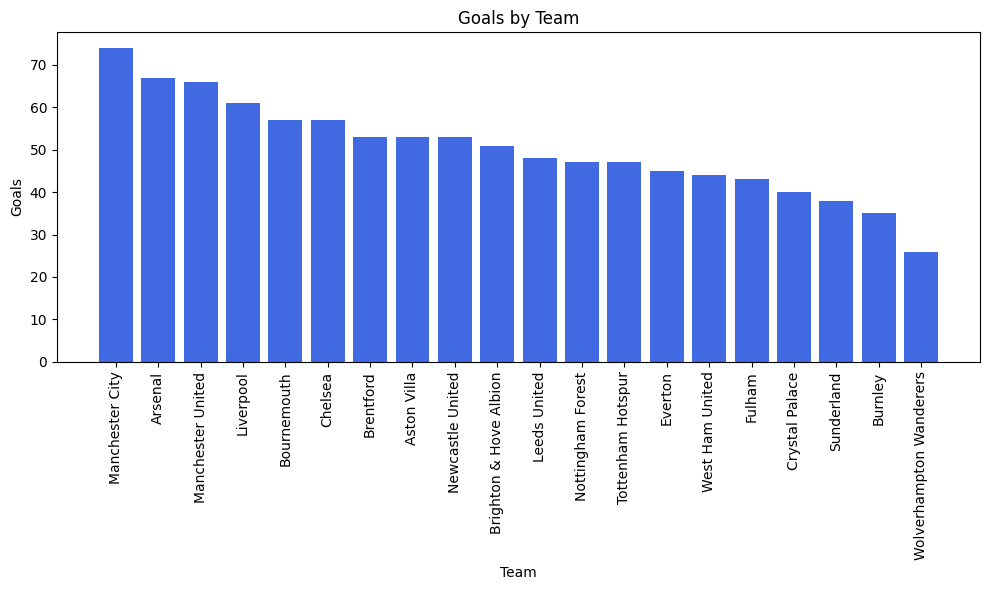

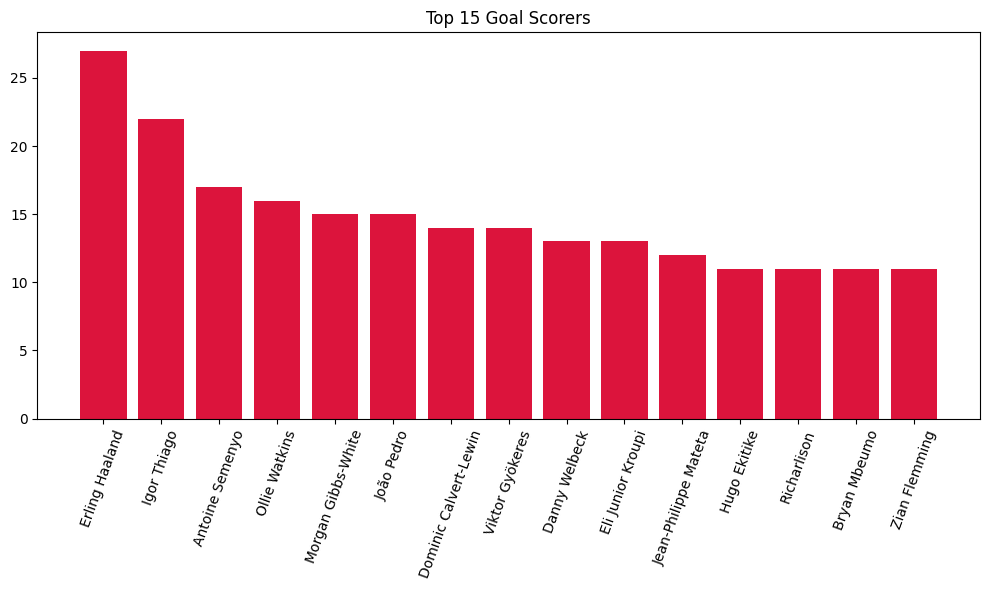

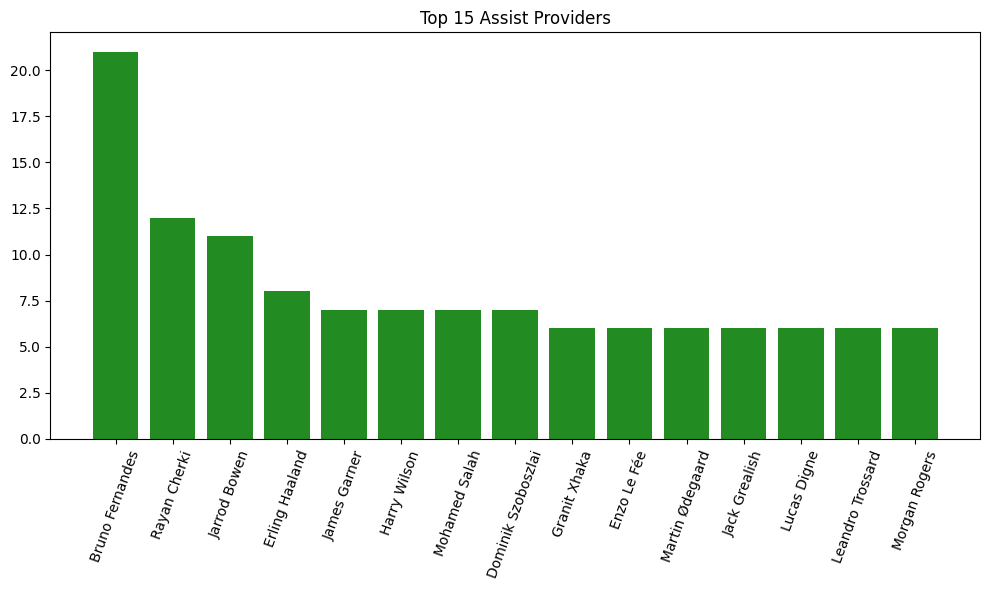

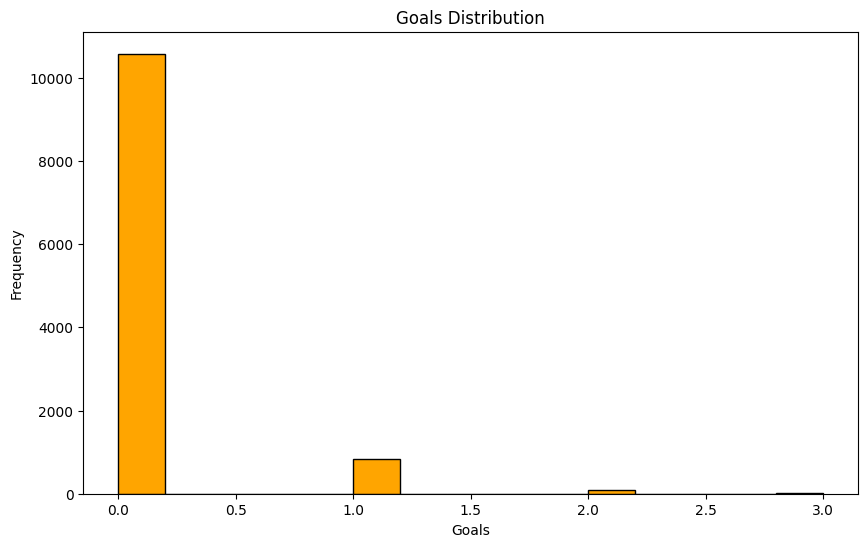

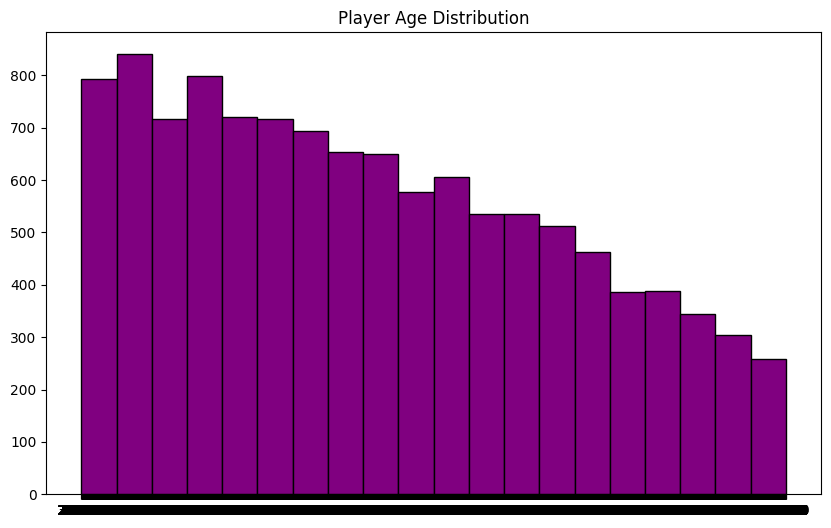

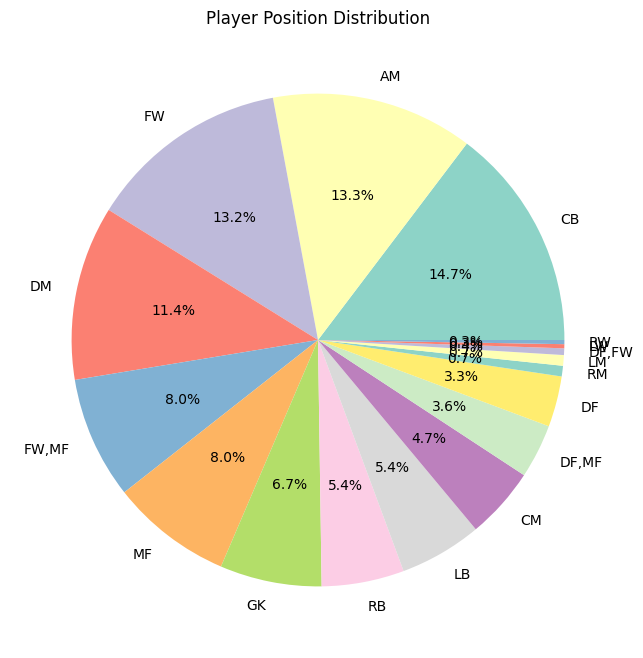

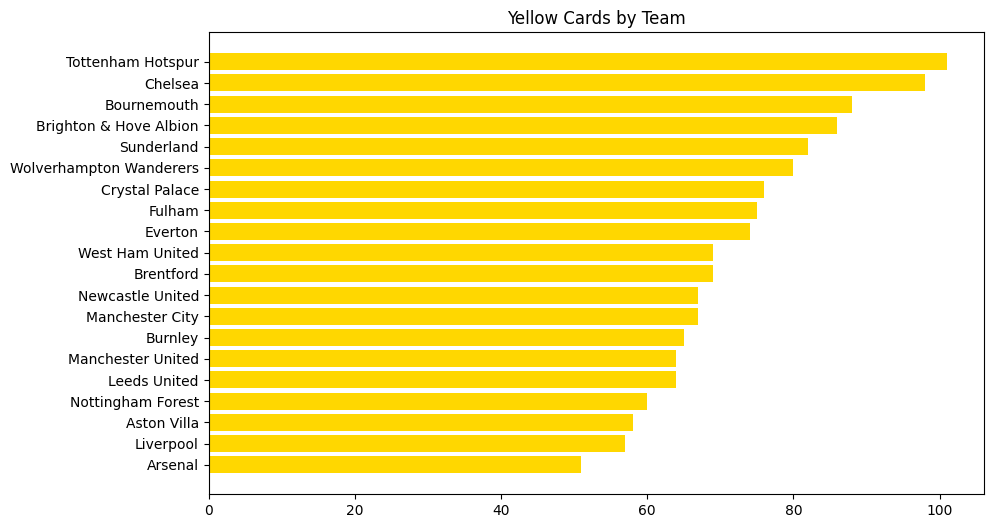

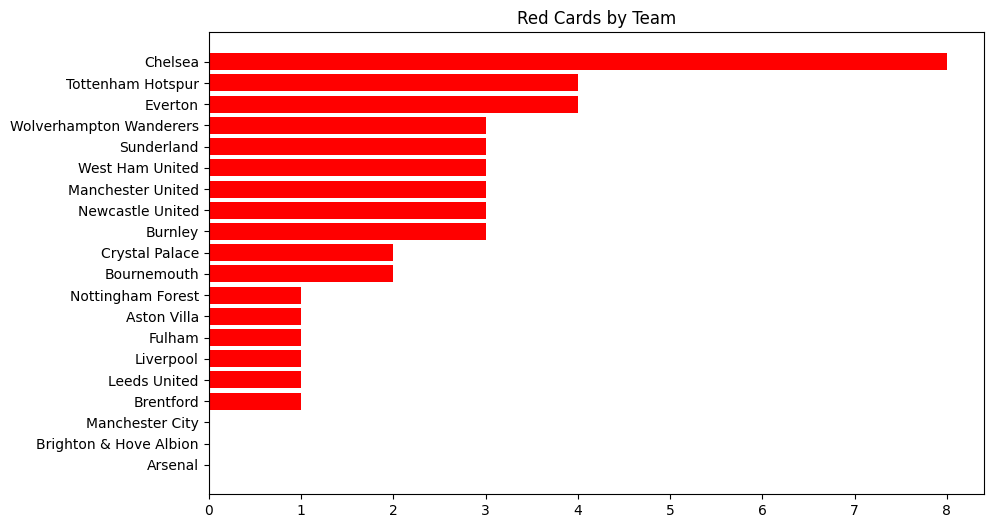

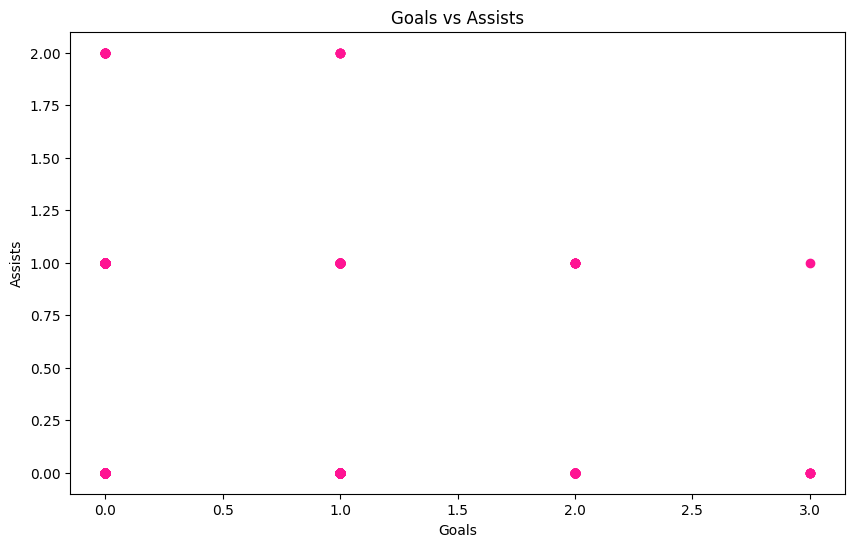

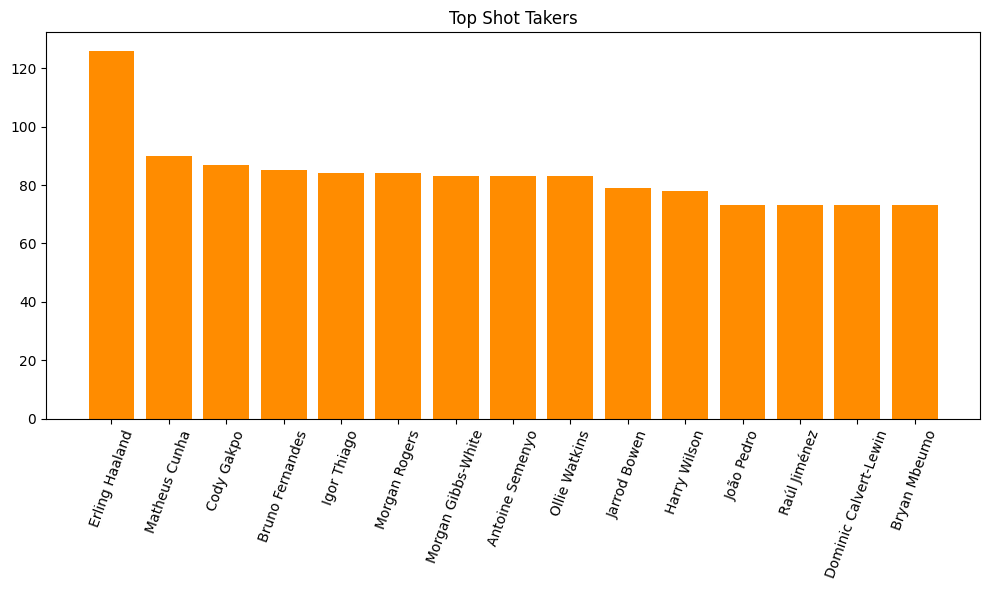

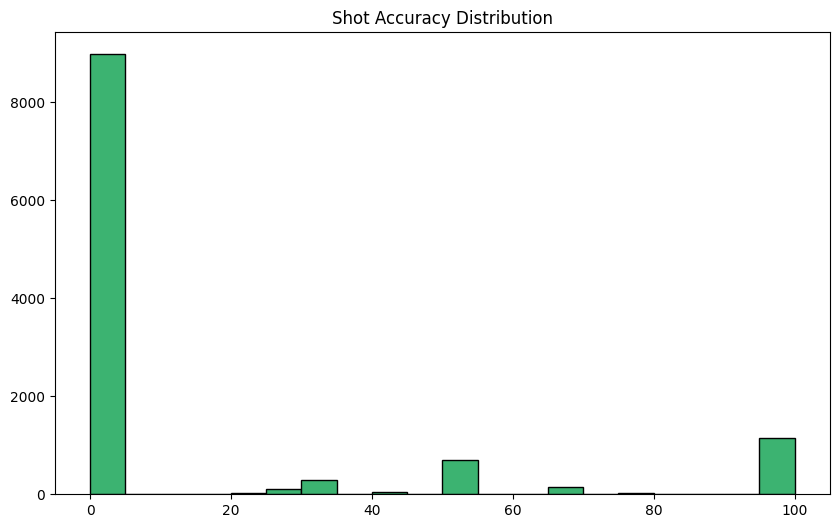

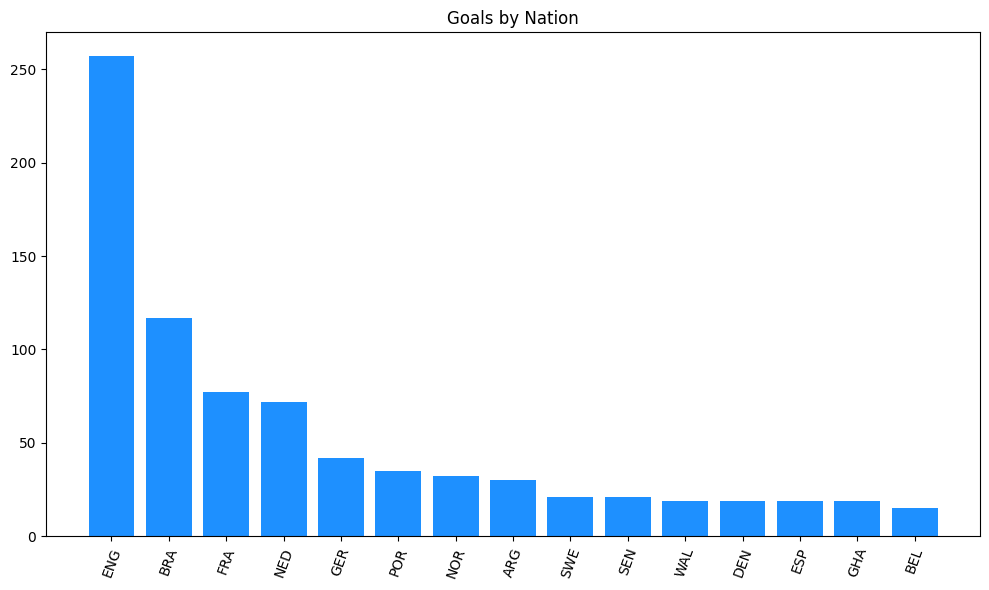

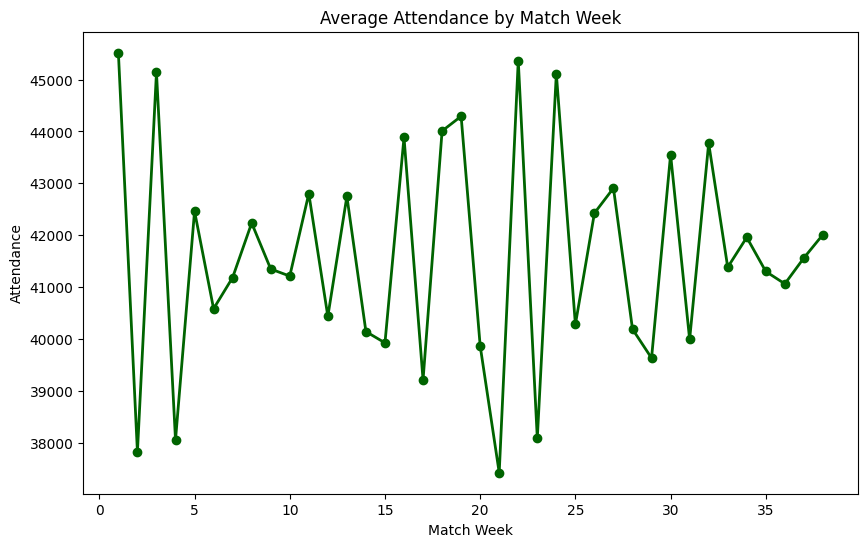

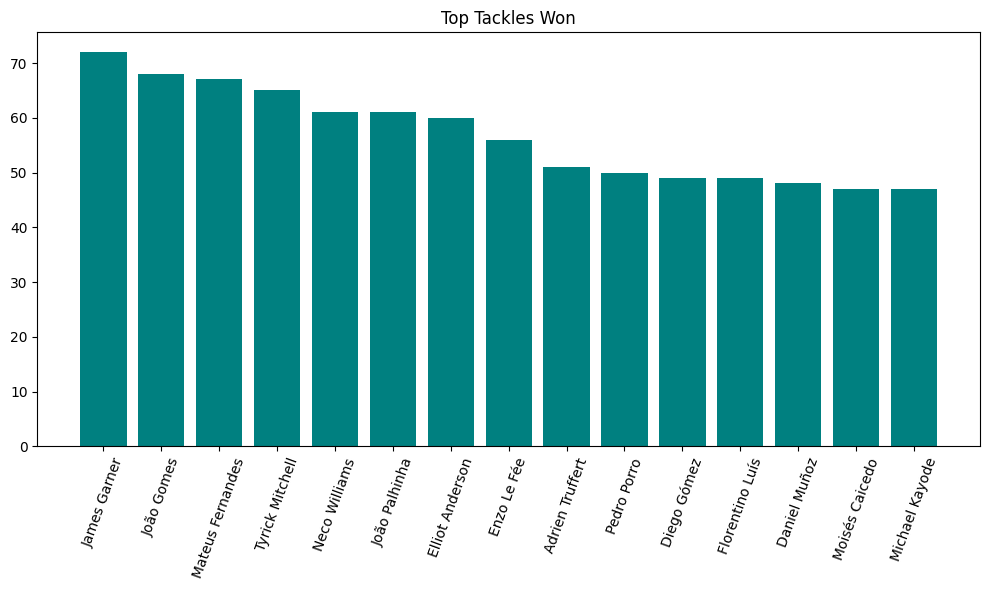

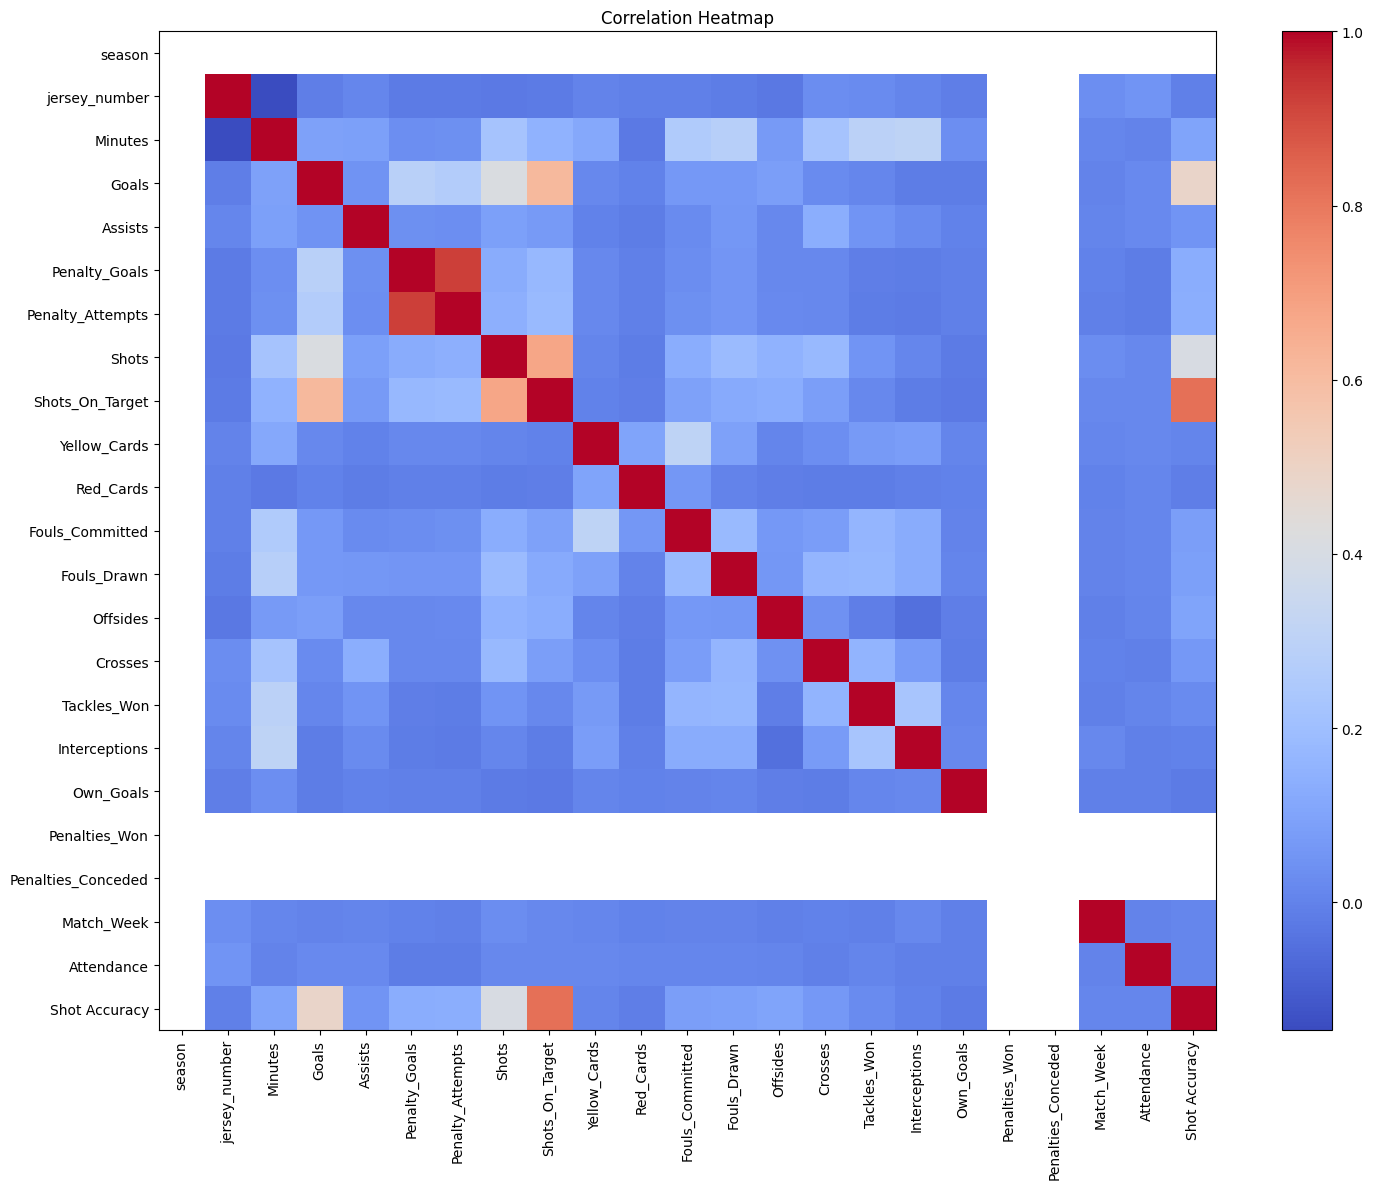

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("/kaggle/input/datasets/abbas829/arsenal-fc-premier-league-champions-campaign/premier_league_player_match_stats.csv")


# Convert Attendance to numeric if needed
df["Attendance"] = (
    df["Attendance"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Attendance"] = pd.to_numeric(df["Attendance"], errors="coerce")

# Shot Accuracy
df["Shot Accuracy"] = (
    (df["Shots_On_Target"] / df["Shots"].replace(0, 1)) * 100
)

# ==========================
# Figure Size
# ==========================
plt.rcParams["figure.figsize"] = (10,6)

# ==========================
# 1. Goals by Team
# ==========================
team_goals = df.groupby("Team")["Goals"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(team_goals.index, team_goals.values, color="royalblue")
plt.xticks(rotation=90)
plt.title("Goals by Team")
plt.xlabel("Team")
plt.ylabel("Goals")
plt.tight_layout()

# ==========================
# 2. Top Goal Scorers
# ==========================
top_goals = df.groupby("Player")["Goals"].sum().sort_values(ascending=False).head(15)

plt.figure()
plt.bar(top_goals.index, top_goals.values, color="crimson")
plt.xticks(rotation=70)
plt.title("Top 15 Goal Scorers")
plt.tight_layout()

# ==========================
# 3. Top Assist Providers
# ==========================
top_assists = df.groupby("Player")["Assists"].sum().sort_values(ascending=False).head(15)

plt.figure()
plt.bar(top_assists.index, top_assists.values, color="forestgreen")
plt.xticks(rotation=70)
plt.title("Top 15 Assist Providers")
plt.tight_layout()

# ==========================
# 4. Goals Distribution
# ==========================
plt.figure()
plt.hist(df["Goals"], bins=15, color="orange", edgecolor="black")
plt.title("Goals Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")

# ==========================
# 5. Age Distribution
# ==========================
plt.figure()
plt.hist(df["Age"], bins=20, color="purple", edgecolor="black")
plt.title("Player Age Distribution")

# ==========================
# 6. Position Distribution
# ==========================
position = df["Position"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(position,
        labels=position.index,
        autopct="%1.1f%%",
        colors=plt.cm.Set3.colors)
plt.title("Player Position Distribution")

# ==========================
# 7. Yellow Cards by Team
# ==========================
yellow = df.groupby("Team")["Yellow_Cards"].sum().sort_values()

plt.figure()
plt.barh(yellow.index, yellow.values, color="gold")
plt.title("Yellow Cards by Team")

# ==========================
# 8. Red Cards by Team
# ==========================
red = df.groupby("Team")["Red_Cards"].sum().sort_values()

plt.figure()
plt.barh(red.index, red.values, color="red")
plt.title("Red Cards by Team")

# ==========================
# 9. Goals vs Assists
# ==========================
plt.figure()
plt.scatter(df["Goals"], df["Assists"], color="deeppink")
plt.xlabel("Goals")
plt.ylabel("Assists")
plt.title("Goals vs Assists")

# ==========================
# 10. Top Shot Takers
# ==========================
shots = df.groupby("Player")["Shots"].sum().sort_values(ascending=False).head(15)

plt.figure()
plt.bar(shots.index, shots.values, color="darkorange")
plt.xticks(rotation=70)
plt.title("Top Shot Takers")
plt.tight_layout()

# ==========================
# 11. Shot Accuracy
# ==========================
plt.figure()
plt.hist(df["Shot Accuracy"].dropna(), bins=20,
         color="mediumseagreen",
         edgecolor="black")
plt.title("Shot Accuracy Distribution")

# ==========================
# 12. Goals by Nation
# ==========================
nation = df.groupby("nation")["Goals"].sum().sort_values(ascending=False).head(15)

plt.figure()
plt.bar(nation.index, nation.values, color="dodgerblue")
plt.xticks(rotation=70)
plt.title("Goals by Nation")
plt.tight_layout()

# ==========================
# 13. Average Attendance
# ==========================
attendance = df.groupby("Match_Week")["Attendance"].mean()

plt.figure()
plt.plot(attendance.index,
         attendance.values,
         color="darkgreen",
         marker="o",
         linewidth=2)
plt.title("Average Attendance by Match Week")
plt.xlabel("Match Week")
plt.ylabel("Attendance")

# ==========================
# 14. Tackles Won
# ==========================
tackles = df.groupby("Player")["Tackles_Won"].sum().sort_values(ascending=False).head(15)

plt.figure()
plt.bar(tackles.index,
        tackles.values,
        color="teal")
plt.xticks(rotation=70)
plt.title("Top Tackles Won")
plt.tight_layout()

# ==========================
# 15. Correlation Heatmap
# ==========================
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(15,12))
plt.imshow(corr,
           cmap="coolwarm",
           aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()

# ==========================
# Show All Plots
# ==========================
plt.show()

## Features Engineering

Model Accuracy: 0.9987

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1039
           1       1.00      1.00      1.00      1260

    accuracy                           1.00      2299
   macro avg       1.00      1.00      1.00      2299
weighted avg       1.00      1.00      1.00      2299



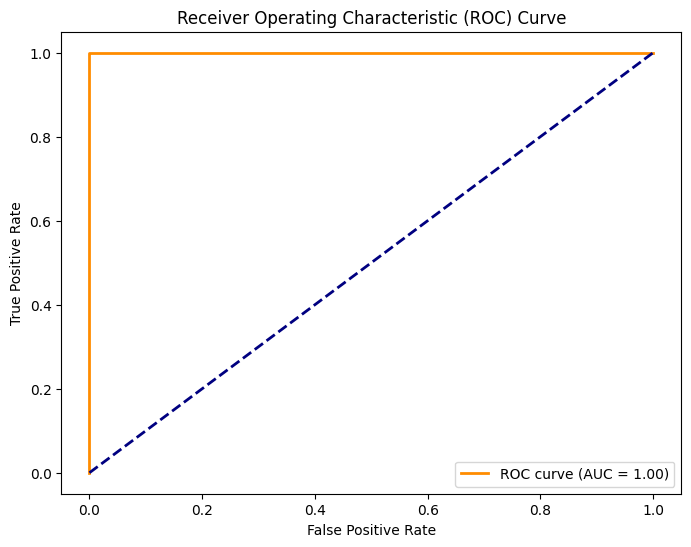

In [11]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

# 1. Load Data
df = pd.read_csv('/kaggle/input/datasets/abbas829/arsenal-fc-premier-league-champions-campaign/premier_league_player_match_stats.csv')

# 2. Data Cleaning & Feature Engineering
# Fix the score parsing using regex to handle all types of dashes/separators
def parse_score_safe(score):
    numbers = re.findall(r'\d+', str(score))
    return int(numbers[0]) + int(numbers[1]) if len(numbers) >= 2 else 0

df['total_goals'] = df['Match_Score'].apply(parse_score_safe)
df['target'] = (df['total_goals'] > 2.5).astype(int)

# Prevent Data Leakage: Drop identifiers and post-match data
cols_to_drop = ['game_id', 'Match_Report', 'Match_Date', 'Kickoff_Time', 'Match_Score', 'total_goals']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], axis=1)

# 3. Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Train-Test Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Prediction and Evaluation
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Visualization: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Thanks.....Please Upvote